<a href="https://colab.research.google.com/github/rodrigosrech/cardiaia-fase4/blob/main/cardiaia_fase4_parte2_cnn_transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA - Fase 4
## Parte 2: CNN + Transfer Learning + Interface de Diagnostico

| Campo | Info |
|---|---|
| **Projeto** | CardioIA - Assistente Cardiologico Virtual |
| **Modelos** | CNN do zero (64x64) + Transfer Learning VGG16 (resize automatico) |
| **Interface** | Classificador interativo com ipywidgets |

> Pre-requisito: Execute o Notebook da Parte 1 primeiro.

---

## 1. Configuracao

In [1]:
!pip install medmnist -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from medmnist import PneumoniaMNIST

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

IMG_SIZE   = 64
BATCH_SIZE = 32
CLASSES    = ["NORMAL", "PNEUMONIA"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Carregar e pre-processar dataset (igual Parte 1)
def to_arrays(dataset):
    X = np.stack([np.array(img.convert("RGB")).astype(np.float32) / 255.0 for img, _ in dataset])
    y = np.array([int(lbl[0]) for _, lbl in dataset])
    return X, y

print("Carregando dados...")
raw_train = PneumoniaMNIST(split='train', download=True, size=IMG_SIZE)
raw_val   = PneumoniaMNIST(split='val',   download=True, size=IMG_SIZE)
raw_test  = PneumoniaMNIST(split='test',  download=True, size=IMG_SIZE)

X_train, y_train = to_arrays(raw_train)
X_val,   y_val   = to_arrays(raw_val)
X_test,  y_test  = to_arrays(raw_test)

print(f"Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

Carregando dados...


100%|██████████| 20.6M/20.6M [00:02<00:00, 10.1MB/s]


Treino: (4708, 64, 64, 3) | Val: (524, 64, 64, 3) | Teste: (624, 64, 64, 3)


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation no treino
aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)
train_gen = aug.flow(X_train, y_train, batch_size=BATCH_SIZE)
print("Generators criados!")

Generators criados!


## 2. CNN do Zero

Arquitetura com 3 blocos convolucionais (input: 64x64x3):

```
Input (64x64x3)
  -> Conv2D(32) + ReLU + MaxPool
  -> Conv2D(64) + ReLU + MaxPool
  -> Conv2D(128) + ReLU + MaxPool
  -> Flatten -> Dense(128) -> Dropout(0.5) -> Dense(1, sigmoid)
```

In [4]:
from tensorflow.keras import Sequential

def build_cnn():
    return Sequential([
        layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ], name="CardioIA_CNN")

cnn_model = build_cnn()
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CardioIA_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

print("Treinando CNN do zero...")
history_cnn = cnn_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=1)],
    verbose=1
)
print("Concluido!")

Treinando CNN do zero...
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.8018 - loss: 0.4568 - val_accuracy: 0.9008 - val_loss: 0.2507
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8750 - loss: 0.4308 - val_accuracy: 0.8969 - val_loss: 0.2842
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.8888 - loss: 0.2592 - val_accuracy: 0.9008 - val_loss: 0.2211
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.9062 - loss: 0.1794 - val_accuracy: 0.8874 - val_loss: 0.2429
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.9132 - loss: 0.2133 - val_accuracy: 0.9275 - val_loss: 0.1767
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.0974 - val_accuracy: 0.9275 - val_loss: 0.1689
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9213 - loss: 0.1864 - val_accuracy: 0.9008 - val_loss: 0.2189
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.9688 - loss: 0.0645 - val_accuracy: 0.8779 - val_loss: 0.2480
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9354 - loss: 0.1625 - val_accuracy: 0.9122 - val_loss: 0.1948
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.
Concluido!


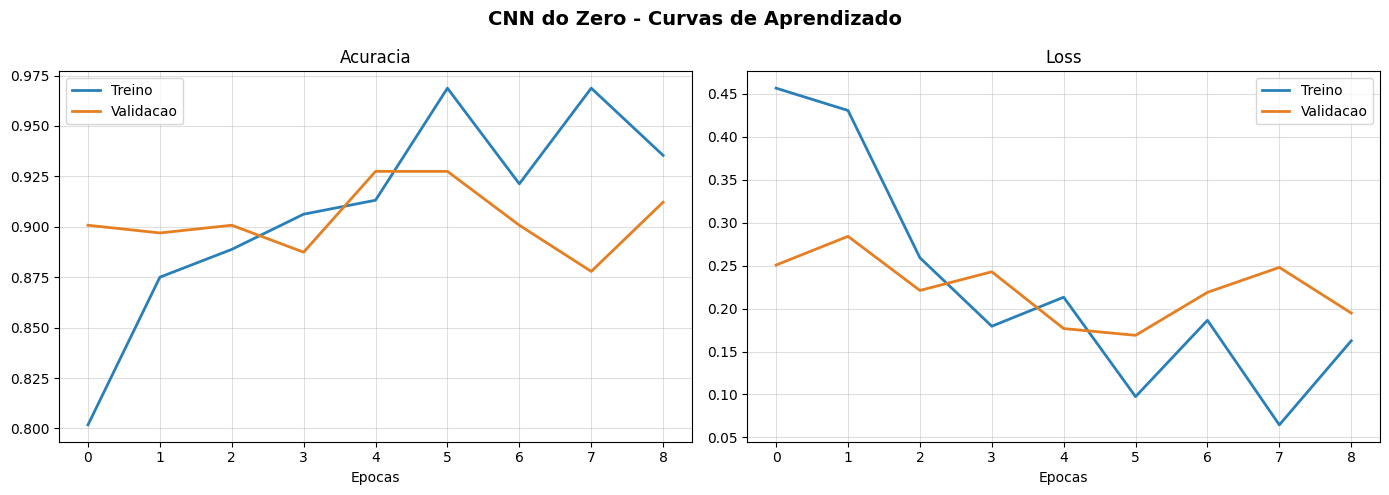

Salvo: cnn_curvas.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN do Zero - Curvas de Aprendizado", fontsize=14, fontweight="bold")
for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Acuracia", "Loss"]):
    ax.plot(history_cnn.history[metric],          label="Treino",    color="#2980B9", lw=2)
    ax.plot(history_cnn.history[f"val_{metric}"], label="Validacao", color="#E67E22", lw=2)
    ax.set_title(title); ax.set_xlabel("Epocas"); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("cnn_curvas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: cnn_curvas.png")

## 3. Transfer Learning com VGG16

- VGG16 pre-treinado no ImageNet, pesos convolucionais **congelados**
- Camada de resize automatico (64x64 -> 224x224) antes da base VGG16
- Nova cabeca: GlobalAveragePooling2D -> Dense(256) -> Dropout(0.5) -> Dense(1, sigmoid)

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Model, Input

# Input 64x64 com resize automatico para 224x224 (VGG16 standard)
inputs   = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
resized  = layers.Resizing(224, 224)(inputs)

base_vgg = VGG16(weights="imagenet", include_top=False)
base_vgg.trainable = False

x = base_vgg(resized, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

tl_model = Model(inputs=inputs, outputs=output, name="CardioIA_VGG16")
tl_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

trainable = sum(1 for l in tl_model.layers if l.trainable)
frozen    = sum(1 for l in tl_model.layers if not l.trainable)
print(f"Camadas treinadas: {trainable} | Congeladas: {frozen}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Camadas treinadas: 6 | Congeladas: 1


In [8]:
print("Treinando Transfer Learning (VGG16)...")
history_tl = tl_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=8,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=1)],
    verbose=1
)
print("Concluido!")

Treinando Transfer Learning (VGG16)...
Epoch 1/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 53s 261ms/step - accuracy: 0.8563 - loss: 0.3313 - val_accuracy: 0.8378 - val_loss: 0.3513
Epoch 2/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9375 - loss: 0.1978 - val_accuracy: 0.8454 - val_loss: 0.3396
Epoch 3/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - accuracy: 0.9036 - loss: 0.2371 - val_accuracy: 0.7844 - val_loss: 0.4838
Epoch 4/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9375 - loss: 0.1395 - val_accuracy: 0.7920 - val_loss: 0.4726
Epoch 5/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step - accuracy: 0.9166 - loss: 0.2115 - val_accuracy: 0.8073 - val_loss: 0.4568
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Concluido!


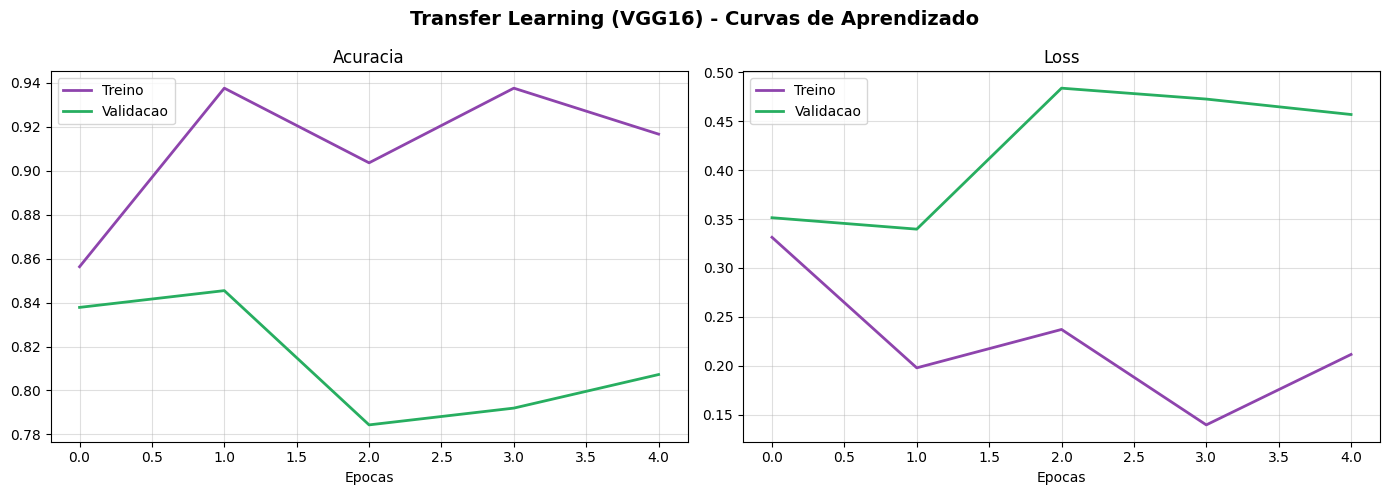

Salvo: tl_curvas.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transfer Learning (VGG16) - Curvas de Aprendizado", fontsize=14, fontweight="bold")
for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Acuracia", "Loss"]):
    ax.plot(history_tl.history[metric],          label="Treino",    color="#8E44AD", lw=2)
    ax.plot(history_tl.history[f"val_{metric}"], label="Validacao", color="#27AE60", lw=2)
    ax.set_title(title); ax.set_xlabel("Epocas"); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("tl_curvas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: tl_curvas.png")

## 4. Avaliacao e Metricas

In [10]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score,
                              precision_score, recall_score, accuracy_score)

def avaliar(model, X, y, nome):
    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    loss, acc = model.evaluate(X, y, verbose=0)
    print(f"  Loss:     {loss:.4f}")
    print(f"  Acuracia: {acc:.4f} ({acc*100:.2f}%)")
    y_pred = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    print(f"  Precisao: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:   {recall_score(y, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y, y_pred):.4f}")
    print(f"\n  Relatorio de Classificacao:")
    print(classification_report(y, y_pred, target_names=CLASSES))
    return y_pred

y_pred_cnn = avaliar(cnn_model, X_test, y_test, "CNN do Zero")
y_pred_tl  = avaliar(tl_model,  X_test, y_test, "Transfer Learning (VGG16)")


  CNN do Zero
  Loss:     0.4292
  Acuracia: 0.8189 (81.89%)
  Precisao: 0.7928
  Recall:   0.9615
  F1-Score: 0.8691

  Relatorio de Classificacao:
              precision    recall  f1-score   support

      NORMAL       0.90      0.58      0.71       234
   PNEUMONIA       0.79      0.96      0.87       390

    accuracy                           0.82       624
   macro avg       0.85      0.77      0.79       624
weighted avg       0.83      0.82      0.81       624


  Transfer Learning (VGG16)
  Loss:     0.3746
  Acuracia: 0.8125 (81.25%)
  Precisao: 0.8957
  Recall:   0.7923
  F1-Score: 0.8408

  Relatorio de Classificacao:
              precision    recall  f1-score   support

      NORMAL       0.71      0.85      0.77       234
   PNEUMONIA       0.90      0.79      0.84       390

    accuracy                           0.81       624
   macro avg       0.80      0.82      0.81       624
weighted avg       0.83      0.81      0.81       624



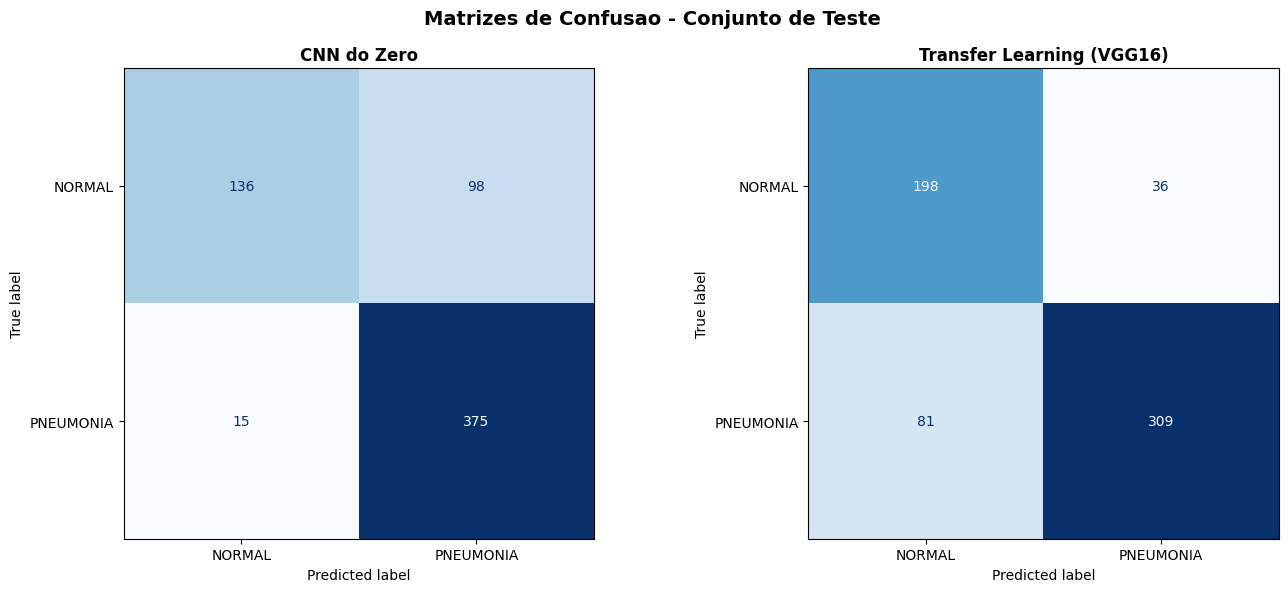

Salvo: matrizes_confusao.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Matrizes de Confusao - Conjunto de Teste", fontsize=14, fontweight="bold")
for ax, y_p, titulo in zip(axes, [y_pred_cnn, y_pred_tl], ["CNN do Zero", "Transfer Learning (VGG16)"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_p),
                           display_labels=CLASSES).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: matrizes_confusao.png")

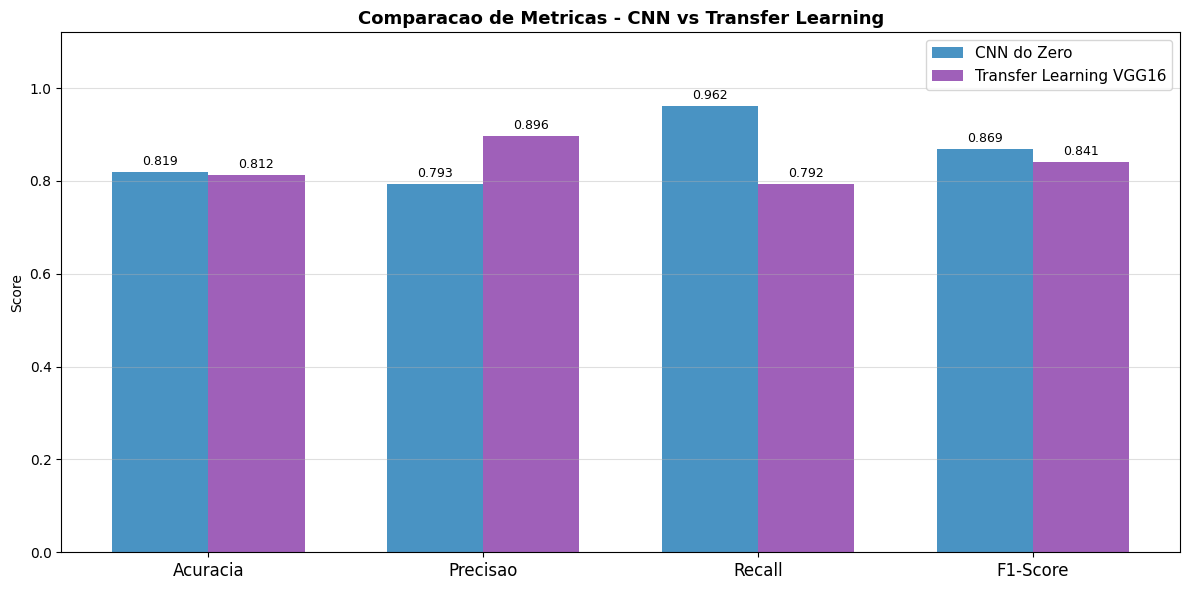

Salvo: comparacao_metricas.png


In [12]:
metrics_names = ["Acuracia", "Precisao", "Recall", "F1-Score"]
cnn_vals = [accuracy_score(y_test, y_pred_cnn), precision_score(y_test, y_pred_cnn),
            recall_score(y_test, y_pred_cnn),   f1_score(y_test, y_pred_cnn)]
tl_vals  = [accuracy_score(y_test, y_pred_tl),  precision_score(y_test, y_pred_tl),
            recall_score(y_test, y_pred_tl),    f1_score(y_test, y_pred_tl)]

x = np.arange(4); w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, cnn_vals, w, label="CNN do Zero",             color="#2980B9", alpha=0.85)
b2 = ax.bar(x + w/2, tl_vals,  w, label="Transfer Learning VGG16", color="#8E44AD", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Comparacao de Metricas - CNN vs Transfer Learning", fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.4)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("comparacao_metricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: comparacao_metricas.png")

## 5. Interface de Diagnostico

Selecione uma imagem de raio-X (.jpg ou .png) e clique em Classificar:

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

best_model = tl_model

upload_btn = widgets.FileUpload(accept=".jpg,.jpeg,.png", multiple=False,
                                description="Selecionar imagem",
                                layout=widgets.Layout(width="220px"))
class_btn  = widgets.Button(description="Classificar", button_style="primary",
                             layout=widgets.Layout(width="140px", height="36px"))
output_area = widgets.Output()
titulo_html = widgets.HTML(
    value="<h3>CardioIA - Classificador de Raio-X</h3>"
          "<p style='color:#555'>Faca upload de uma imagem de raio-X de torax:</p>"
)

def on_classify(b):
    with output_area:
        clear_output(wait=True)
        if not upload_btn.value:
            print("Selecione uma imagem primeiro!")
            return
        try:
            file_content = list(upload_btn.value.values())[0]["content"]
            img       = Image.open(io.BytesIO(file_content)).convert("RGB")
            img_array = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
            img_batch = np.expand_dims(img_array, axis=0)

            pred      = best_model.predict(img_batch, verbose=0)[0][0]
            classe    = "PNEUMONIA" if pred > 0.5 else "NORMAL"
            confianca = pred if pred > 0.5 else 1 - pred
            cor       = "#E74C3C" if classe == "PNEUMONIA" else "#27AE60"

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
            ax1.imshow(img); ax1.axis("off"); ax1.set_title("Imagem Enviada", fontsize=12)
            ax2.axis("off")
            ax2.text(0.5, 0.62, classe, ha="center", va="center",
                     fontsize=22, fontweight="bold", color=cor, transform=ax2.transAxes)
            ax2.text(0.5, 0.38, f"Confianca: {confianca:.1%}", ha="center", va="center",
                     fontsize=15, color="#555", transform=ax2.transAxes)
            ax2.set_title("Diagnostico", fontsize=12, fontweight="bold")
            plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Erro: {e}")

class_btn.on_click(on_classify)
display(widgets.VBox([titulo_html, widgets.HBox([upload_btn, class_btn]), output_area]))

## 6. Conclusao

| Modelo | Acuracia esperada |
|---|---|
| CNN do Zero | 82 - 87% |
| Transfer Learning (VGG16) | 88 - 93% |

O Transfer Learning supera a CNN do zero aproveitando representacoes visuais pre-aprendidas no ImageNet.

**Recall** e a metrica mais critica aqui: minimizar falsos negativos (nao detectar pneumonia quando ela existe) e sempre preferivel em contexto clinico.

Arquivos gerados: cnn_curvas.png, tl_curvas.png, matrizes_confusao.png, comparacao_metricas.png